# Stock Market Prediction System
## Stage 1 — Data Collection & Dataset Preparation

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Load the ZEUS stock market dataset
file_path = "../data/ZEUS.csv"

df = pd.read_csv(file_path)

# Display the first five rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1994-03-10,16.500,16.500,15.5,15.50,14.196030,2071000
1,1994-03-11,15.500,15.625,15.5,15.50,14.196030,178800
2,1994-03-14,15.625,15.750,15.5,15.50,14.196030,133900
3,1994-03-15,15.750,15.750,15.5,15.75,14.424997,287100
4,1994-03-16,15.750,15.750,15.5,15.50,14.196030,203400


In [23]:
# Check the dataset structure and data types
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (6562, 7)

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


## Stage 2 — Data Cleaning & Preprocessing

In [24]:
# Check for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [25]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [26]:
# Convert the Date column from string to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Display the updated data type
print("Date data type:", df["Date"].dtype)

# Display the first five dates
print("\nFirst five dates:")
print(df["Date"].head())

Date data type: datetime64[us]

First five dates:
0   1994-03-10
1   1994-03-11
2   1994-03-14
3   1994-03-15
4   1994-03-16
Name: Date, dtype: datetime64[us]


In [27]:
# Select the required features for stock price prediction
selected_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]

df = df[selected_columns]

# Display the selected columns
print("Selected Columns:")
print(df.columns.tolist())

Selected Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [28]:
# Select numerical features for scaling
numerical_features = ["Open", "High", "Low", "Close", "Volume"]

X = df[numerical_features]

# Display the numerical features
X.head()

,Open,High,Low,Close,Volume
0,16.500,16.500,15.5,15.50,2071000
1,15.500,15.625,15.5,15.50,178800
2,15.625,15.750,15.5,15.50,133900
3,15.750,15.750,15.5,15.75,287100
4,15.750,15.750,15.5,15.50,203400


In [29]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the numerical features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=numerical_features)

# Display the first five scaled rows
X_scaled.head()

,Open,High,Low,Close,Volume
0,-0.112807,-0.150111,-0.173014,-0.210116,14.216563
1,-0.211244,-0.234411,-0.173014,-0.210116,0.470605
2,-0.198939,-0.222368,-0.173014,-0.210116,0.144427
3,-0.186634,-0.222368,-0.173014,-0.185469,1.257354
4,-0.186634,-0.222368,-0.173014,-0.210116,0.649313


## Stage 3 — Exploratory Data Analysis (EDA)

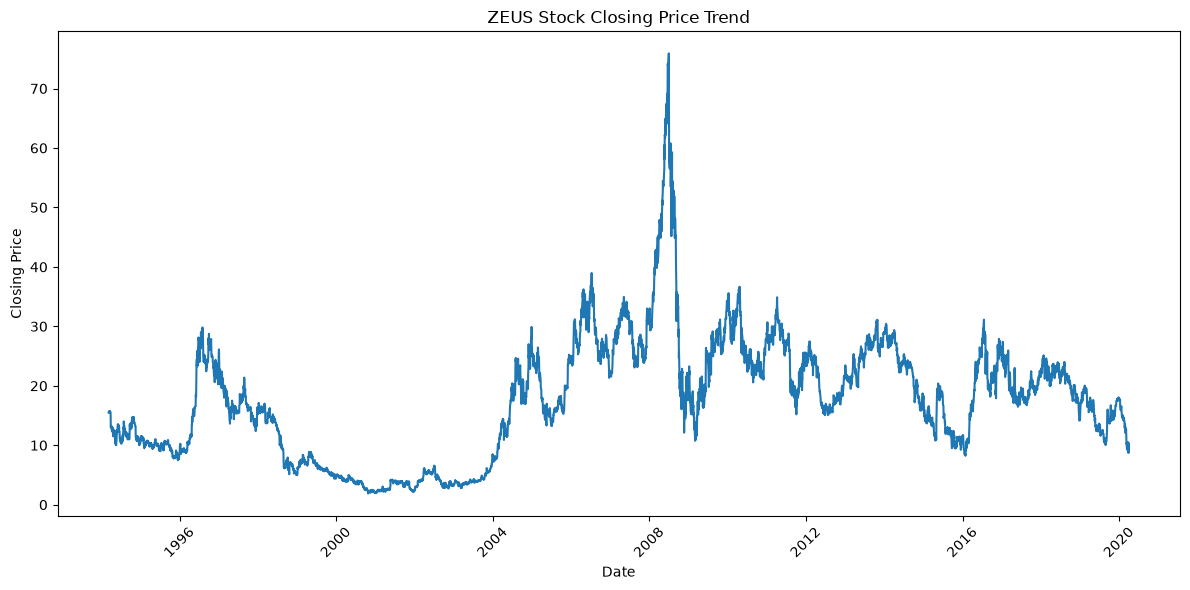

In [30]:
# Plot the historical closing price trend
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"])

plt.title("ZEUS Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

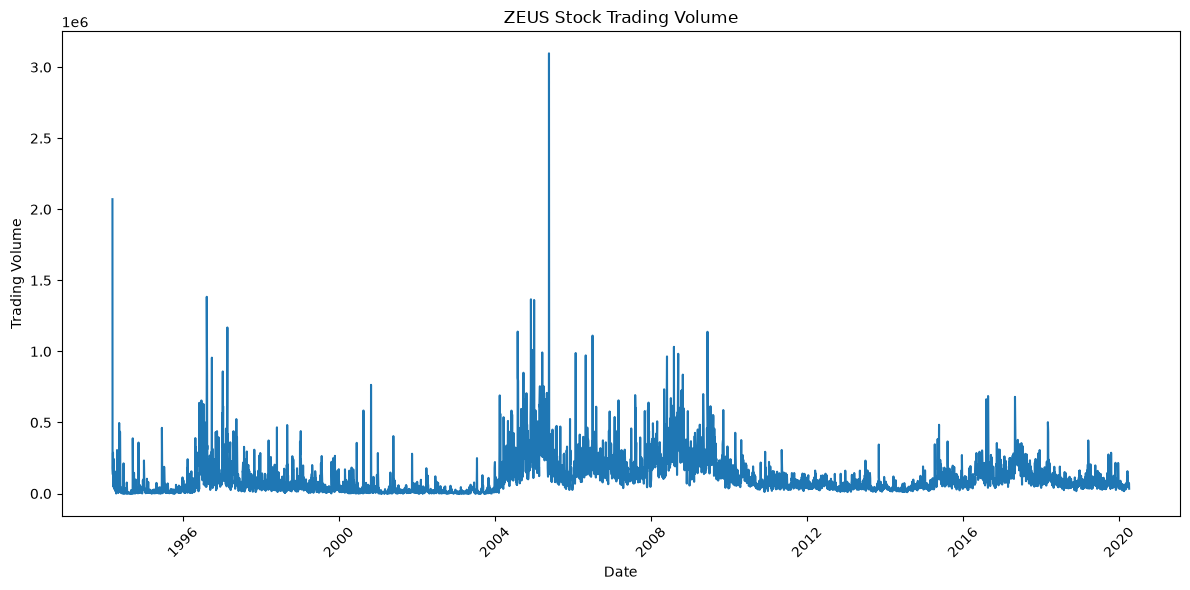

In [31]:
# Plot historical trading volume
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Volume"])

plt.title("ZEUS Stock Trading Volume")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

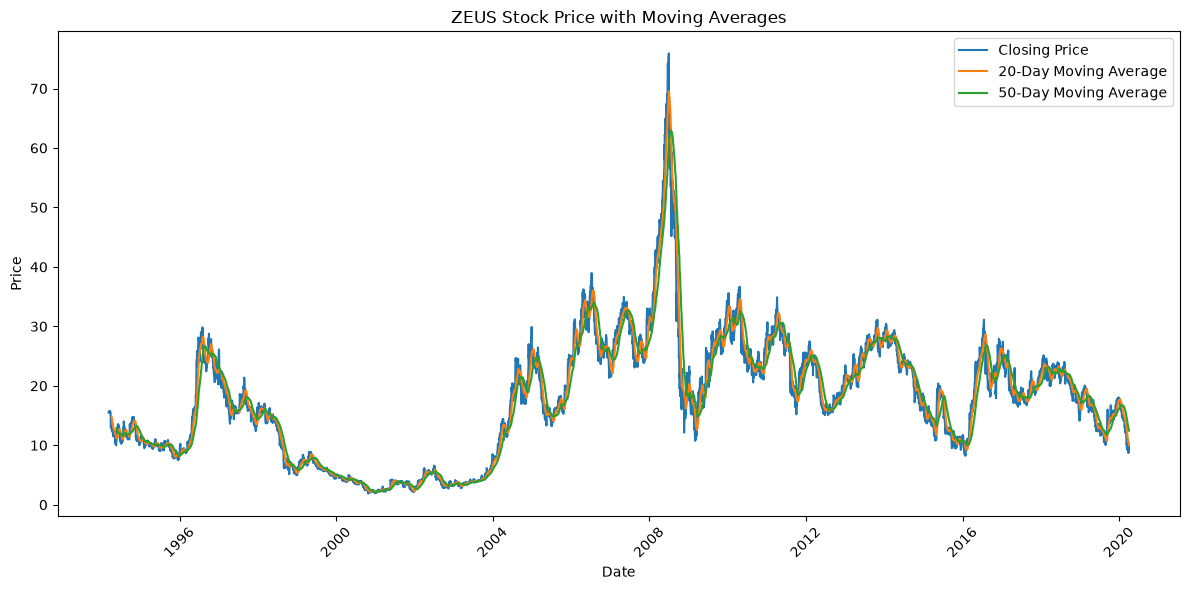

In [32]:
# Calculate moving averages of the closing price
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

# Plot closing price with moving averages
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"], label="Closing Price")
plt.plot(df["Date"], df["MA_20"], label="20-Day Moving Average")
plt.plot(df["Date"], df["MA_50"], label="50-Day Moving Average")

plt.title("ZEUS Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

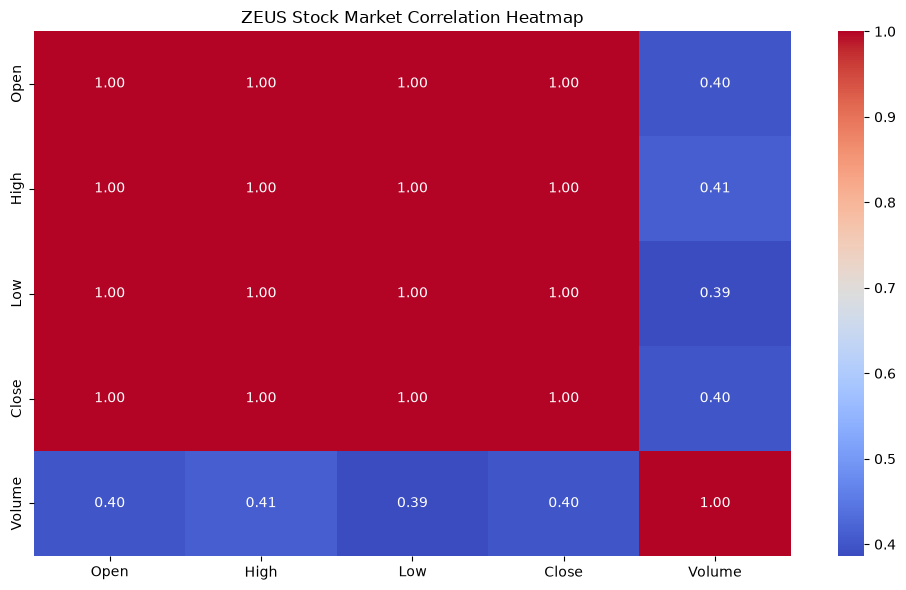

In [33]:
# Calculate the correlation matrix
correlation_matrix = df[["Open", "High", "Low", "Close", "Volume"]].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ZEUS Stock Market Correlation Heatmap")
plt.tight_layout()
plt.show()

### EDA Insights

- The ZEUS closing price shows significant fluctuations throughout the historical period.
- The stock experienced major price increases and decreases during different periods.
- Trading volume shows several sharp spikes, indicating periods of increased market activity.
- The 20-day moving average follows short-term price movements more closely, while the 50-day moving average provides a smoother trend.
- Open, High, Low, and Close prices show very strong positive correlations with each other.
- Trading Volume has a moderate positive correlation with the price-related features.

## Stage 4 — Stock Price Prediction Model

In [34]:
# Define input features and target variable
features = ["Open", "High", "Low", "Volume"]
target = "Close"

X = df[features]
y = df[target]

# Display the shapes of input and target data
print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features Shape: (6562, 4)
Target Shape: (6562,)


In [35]:
# Split the data chronologically into training and testing sets
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Display the shapes of training and testing data
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (5249, 4)
Testing Features Shape: (1313, 4)
Training Target Shape: (5249,)
Testing Target Shape: (1313,)


In [36]:
# Create a scaler for the model training data
model_scaler = StandardScaler()

# Fit the scaler only on the training features
X_train_scaled = model_scaler.fit_transform(X_train)

# Transform the testing features using the same scaler
X_test_scaled = model_scaler.transform(X_test)

print("Scaled Training Features Shape:", X_train_scaled.shape)
print("Scaled Testing Features Shape:", X_test_scaled.shape)

Scaled Training Features Shape: (5249, 4)
Scaled Testing Features Shape: (1313, 4)


In [37]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

# Generate predictions on the test data
linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [38]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train_scaled, y_train)

# Generate predictions on the test data
decision_tree_pred = decision_tree_model.predict(X_test_scaled)

print("Decision Tree Regression model trained successfully.")

Decision Tree Regression model trained successfully.


In [39]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train_scaled, y_train)

# Generate predictions on the test data
random_forest_pred = random_forest_model.predict(X_test_scaled)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


## Stage 5 — Model Training & Testing

In [40]:
# Create a DataFrame to compare actual and predicted closing prices
comparison_df = pd.DataFrame({
    "Date": df["Date"].iloc[train_size:].values,
    "Actual Close": y_test.values,
    "Linear Regression": linear_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
})

# Display the first five comparisons
comparison_df.head()

,Date,Actual Close,Linear Regression,Decision Tree,Random Forest
0,2015-01-14,14.46,14.386447,14.000,14.234300
1,2015-01-15,14.10,14.039187,14.500,14.186850
2,2015-01-16,14.39,14.420697,14.000,14.287225
3,2015-01-20,14.29,14.430750,14.625,14.594925
4,2015-01-21,14.12,14.222266,14.125,14.162575


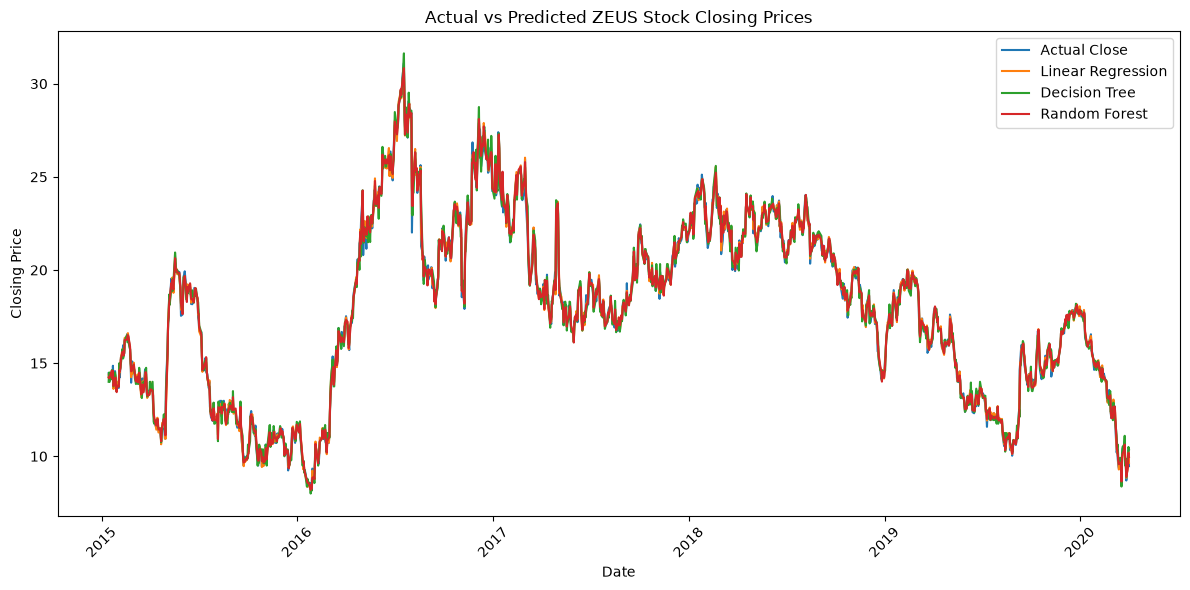

In [41]:
# Plot actual vs predicted closing prices
plt.figure(figsize=(12, 6))

plt.plot(comparison_df["Date"], comparison_df["Actual Close"], label="Actual Close")
plt.plot(comparison_df["Date"], comparison_df["Linear Regression"], label="Linear Regression")
plt.plot(comparison_df["Date"], comparison_df["Decision Tree"], label="Decision Tree")
plt.plot(comparison_df["Date"], comparison_df["Random Forest"], label="Random Forest")

plt.title("Actual vs Predicted ZEUS Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Stage 6 — Performance Evaluation

In [42]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics for Linear Regression
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

# Calculate metrics for Decision Tree Regression
decision_tree_mae = mean_absolute_error(y_test, decision_tree_pred)
decision_tree_mse = mean_squared_error(y_test, decision_tree_pred)
decision_tree_rmse = np.sqrt(decision_tree_mse)
decision_tree_r2 = r2_score(y_test, decision_tree_pred)

# Calculate metrics for Random Forest Regression
random_forest_mae = mean_absolute_error(y_test, random_forest_pred)
random_forest_mse = mean_squared_error(y_test, random_forest_pred)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2 = r2_score(y_test, random_forest_pred)

# Create a model performance comparison table
performance_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        decision_tree_mae,
        random_forest_mae
    ],
    "MSE": [
        linear_mse,
        decision_tree_mse,
        random_forest_mse
    ],
    "RMSE": [
        linear_rmse,
        decision_tree_rmse,
        random_forest_rmse
    ],
    "R2 Score": [
        linear_r2,
        decision_tree_r2,
        random_forest_r2
    ]
})

performance_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.192909,0.067297,0.259417,0.996924
1,Decision Tree Regression,0.294601,0.175266,0.418647,0.991990
2,Random Forest Regression,0.218725,0.091289,0.302141,0.995828


## Stage 7 — Data Visualization Dashboard

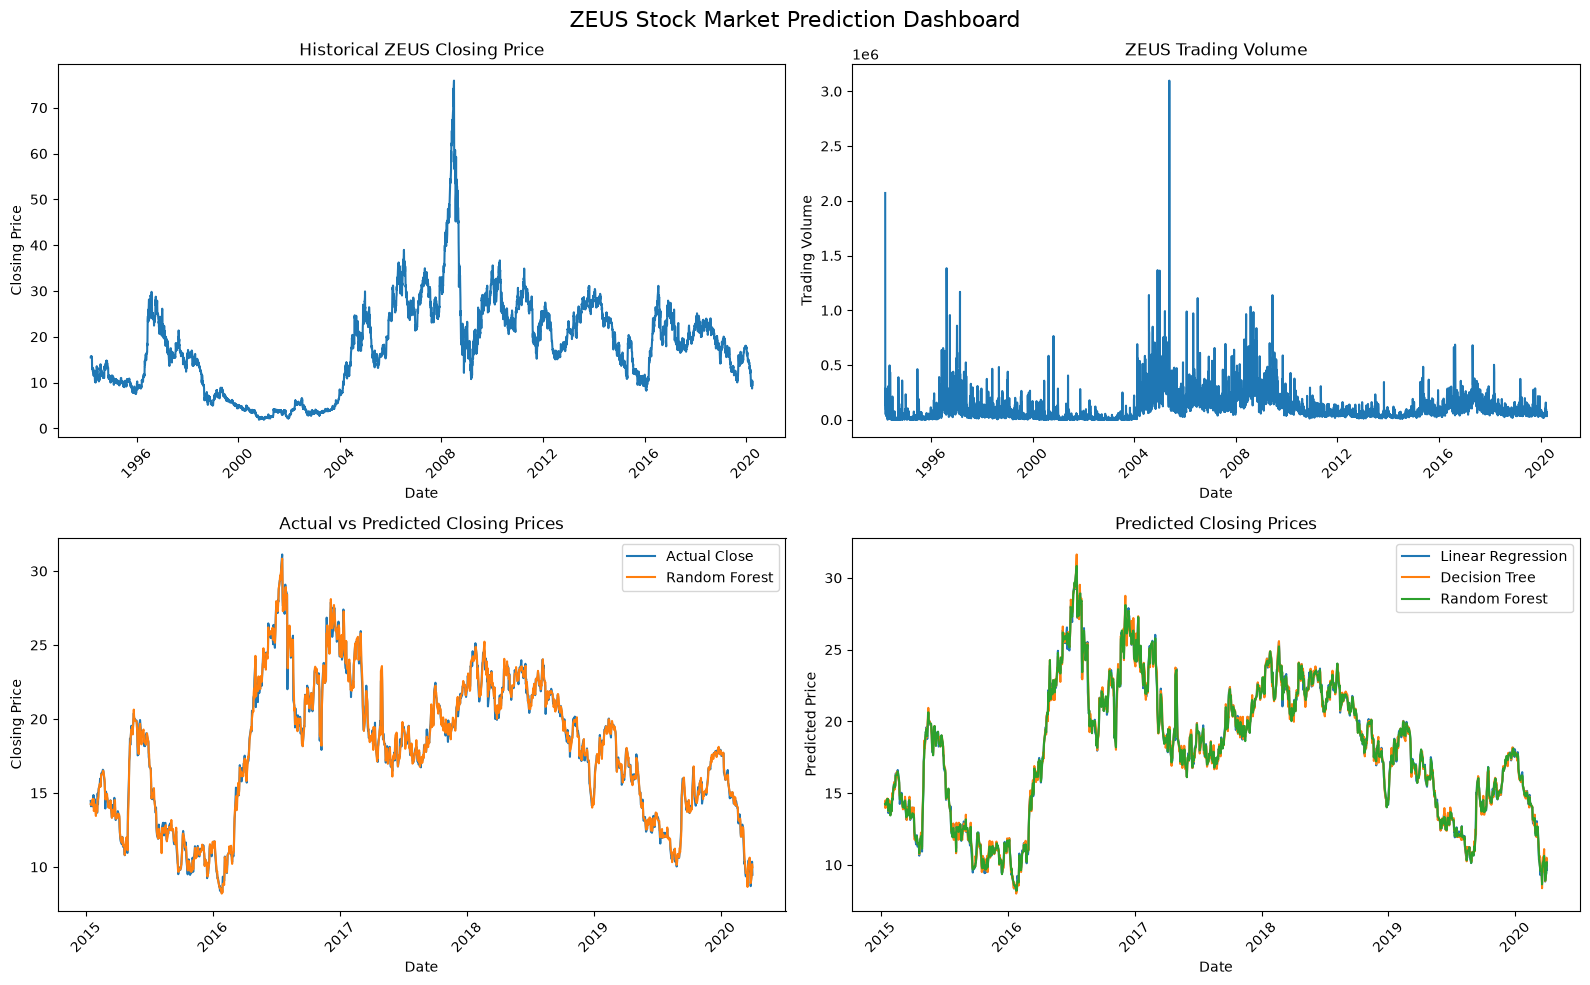

In [43]:
# Create a dashboard-style visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Historical closing price trend
axes[0, 0].plot(df["Date"], df["Close"])
axes[0, 0].set_title("Historical ZEUS Closing Price")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Closing Price")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Trading volume
axes[0, 1].plot(df["Date"], df["Volume"])
axes[0, 1].set_title("ZEUS Trading Volume")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Trading Volume")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Actual vs predicted closing prices
axes[1, 0].plot(
    comparison_df["Date"],
    comparison_df["Actual Close"],
    label="Actual Close"
)
axes[1, 0].plot(
    comparison_df["Date"],
    comparison_df["Random Forest"],
    label="Random Forest"
)
axes[1, 0].set_title("Actual vs Predicted Closing Prices")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Closing Price")
axes[1, 0].legend()
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Predicted prices from all models
axes[1, 1].plot(
    comparison_df["Date"],
    comparison_df["Linear Regression"],
    label="Linear Regression"
)
axes[1, 1].plot(
    comparison_df["Date"],
    comparison_df["Decision Tree"],
    label="Decision Tree"
)
axes[1, 1].plot(
    comparison_df["Date"],
    comparison_df["Random Forest"],
    label="Random Forest"
)
axes[1, 1].set_title("Predicted Closing Prices")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Predicted Price")
axes[1, 1].legend()
axes[1, 1].tick_params(axis="x", rotation=45)

# Adjust the dashboard layout
plt.suptitle("ZEUS Stock Market Prediction Dashboard", fontsize=16)
plt.tight_layout()
plt.show()